# Self-Attention 최소 예제

이 노트북은 **한 토큰의 표현이 다른 토큰 정보를 어떻게 섞어 문맥화되는지**만 보여주는 아주 작은 예제입니다.

사용하는 식은 다음과 같습니다.

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

설명을 단순하게 하기 위해 이번에는 $W_Q, W_K, W_V$를 모두 항등행렬로 두어 `Q = K = V = X` 로 시작합니다.

In [2]:
import numpy as np

np.set_printoptions(precision=3, suppress=True)

# 문장: "나는 사과를 먹었다"
tokens = ["나는", "사과를", "먹었다"]

# 각 토큰의 toy embedding (실제 모델에서는 학습된 고차원 벡터)
# 의도적으로 '사과를'과 '먹었다'가 비슷한 방향을 갖게 만들었다.
X = np.array([
    [1.0, 0.0, 0.0],   # 나는
    [0.0, 1.0, 1.0],   # 사과를
    [0.0, 1.0, 0.8],   # 먹었다
])

print("tokens:", tokens)
print("\nX =")
print(X)

tokens: ['나는', '사과를', '먹었다']

X =
[[1.  0.  0. ]
 [0.  1.  1. ]
 [0.  1.  0.8]]


## 1. Q, K, V 만들기

실제 Transformer에서는 보통 아래처럼 서로 다른 학습 파라미터를 곱합니다.

$$Q=XW_Q, \quad K=XW_K, \quad V=XW_V$$

여기서는 Attention 자체의 동작만 보기 위해 세 행렬을 항등행렬로 둡니다.

In [3]:
d_model = X.shape[1]
I = np.eye(d_model)

W_Q = I
W_K = I
W_V = I

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

print("Q =\n", Q)
print("\nK =\n", K)
print("\nV =\n", V)

Q =
 [[1.  0.  0. ]
 [0.  1.  1. ]
 [0.  1.  0.8]]

K =
 [[1.  0.  0. ]
 [0.  1.  1. ]
 [0.  1.  0.8]]

V =
 [[1.  0.  0. ]
 [0.  1.  1. ]
 [0.  1.  0.8]]


## 2. 토큰끼리 관련도 계산

`Q @ K.T`의 `(i, j)` 값은 **i번째 토큰이 j번째 토큰을 얼마나 참고하려 하는지**를 나타내는 raw score입니다.

그 뒤 $\sqrt{d_k}$로 나눠 값의 크기를 안정화합니다.

In [4]:
d_k = K.shape[1]

raw_scores = Q @ K.T
scaled_scores = raw_scores / np.sqrt(d_k)

print("QK^T =")
print(raw_scores)
print("\nscaled scores =")
print(scaled_scores)

QK^T =
[[1.   0.   0.  ]
 [0.   2.   1.8 ]
 [0.   1.8  1.64]]

scaled scores =
[[0.577 0.    0.   ]
 [0.    1.155 1.039]
 [0.    1.039 0.947]]


## 3. Softmax로 Attention Weight 만들기

각 행마다 softmax를 적용하면, 한 토큰이 모든 토큰에 배분하는 관심도의 합이 1이 됩니다.

In [5]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

attention_weights = softmax(scaled_scores, axis=-1)

print("attention weights =")
print(attention_weights)
print("\n각 행의 합 =", attention_weights.sum(axis=1))

# '먹었다' 토큰이 누구를 얼마나 보는지 따로 확인
target_idx = tokens.index("먹었다")
print("\n'먹었다'의 attention:")
for token, weight in zip(tokens, attention_weights[target_idx]):
    print(f"  {token:4s}: {weight:.3f}")

attention weights =
[[0.471 0.264 0.264]
 [0.143 0.453 0.404]
 [0.156 0.441 0.402]]

각 행의 합 = [1. 1. 1.]

'먹었다'의 attention:
  나는  : 0.156
  사과를 : 0.441
  먹었다 : 0.402


위 toy embedding에서는 `먹었다`가 `사과를`과 벡터 방향이 비슷하기 때문에, `나는`보다 `사과를`에 더 큰 attention weight를 줍니다.

즉 **Attention은 단순히 점수만 계산하는 것이 아니라, 그 점수를 이용해 다른 토큰의 정보를 실제 출력 벡터에 섞습니다.**

## 4. V를 가중합해서 문맥화된 토큰 표현 만들기

$$O = AV$$

여기서 $A$는 attention weight입니다. 출력의 각 행은 원래 한 토큰 벡터가 아니라 **다른 토큰들의 V가 섞인 새로운 표현**입니다.

In [6]:
output = attention_weights @ V

print("원래 X =")
print(X)
print("\nAttention 이후 output =")
print(output)

print("\n'먹었다' 원래 벡터:")
print(X[target_idx])
print("\n'먹었다' Attention 이후 벡터:")
print(output[target_idx])

원래 X =
[[1.  0.  0. ]
 [0.  1.  1. ]
 [0.  1.  0.8]]

Attention 이후 output =
[[0.471 0.529 0.476]
 [0.143 0.857 0.776]
 [0.156 0.844 0.763]]

'먹었다' 원래 벡터:
[0.  1.  0.8]

'먹었다' Attention 이후 벡터:
[0.156 0.844 0.763]


## 핵심 해석

- 입력 단계의 `먹었다` 벡터는 자기 자신의 embedding일 뿐입니다.
- Attention weight를 계산하면서 `먹었다`가 `나는`, `사과를`, `먹었다`를 각각 얼마나 참고할지 정합니다.
- 마지막 `attention_weights @ V`에서 실제로 다른 토큰 정보가 섞입니다.
- 따라서 Attention을 지나간 뒤의 `먹었다` 벡터는 **문장 안에서의 문맥을 반영한 representation**이 됩니다.

실제 Transformer에서는 이 과정에 **학습된 $W_Q, W_K, W_V$**, **Multi-Head Attention**, **Residual connection**, **LayerNorm**, **MLP/FFN** 등이 추가됩니다.

## (선택) Attention matrix를 눈으로 보기

행은 Query 토큰, 열은 Key 토큰입니다.

c:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\.venv\Lib\site-packages\IPython\core\pylabto

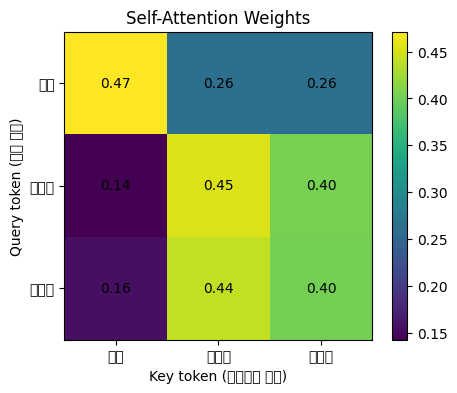

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(attention_weights)

ax.set_xticks(range(len(tokens)), labels=tokens)
ax.set_yticks(range(len(tokens)), labels=tokens)
ax.set_xlabel("Key token (참고되는 토큰)")
ax.set_ylabel("Query token (현재 토큰)")
ax.set_title("Self-Attention Weights")

for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f"{attention_weights[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.show()